# From raw CML signals to a rainfall map, end to end

One day of the OpenMRG network (Gothenburg, 28 July 2015, the Torslanda
convective event) through every stage: **pull** the data, **look** at it,
**retrieve** rain, **score** it against radar and gauges, **improve** it, and
**map** it. Every call is `core.opensense` (or the project's `merging`
wrapper), so the same lines work on OpenRainER and on the full archives.
About a minute, offline once the subset is cached.

In [1]:
import sys
from pathlib import Path

from core import viz_style as vs
from core.opensense import evaluation as ev, example_data, plots, retrieval as rt

sys.path.insert(0, str(Path.cwd().parent / "src"))
import merging

vs.use_style()

## 1. Pull

`load` downloads on first use, caches, and normalizes: km / GHz / mm h⁻¹
whatever the file declared, one polarization spelling, projected coordinates,
and a rain rate `R` for gauges and radar. `time=` selects before reading
(the 8-day CML file is 1.2 GB in memory). The full Zenodo records go through
`python -m core.opensense.fetch` instead.

In [2]:
data = example_data.load("openmrg", "8d", time=slice("2015-07-28T06", "2015-07-28T23"),
                         verbose=False)
cml, radar, gauges = data["cml"], data["radar"], data["gauge_municipal"]
{name: dict(ds.sizes) for name, ds in data.items()}

{'cml': {'sublink_id': 2, 'cml_id': 364, 'time': 6480},
 'radar': {'time': 216, 'y': 48, 'x': 37},
 'gauge_municipal': {'id': 10, 'time': 1080},
 'gauge_smhi': {'id': 1, 'time': 72}}

## 2. Look

A link measures a path average, a radar pixel an area, a gauge a point.
Short, low-frequency links cannot resolve light rain at all.

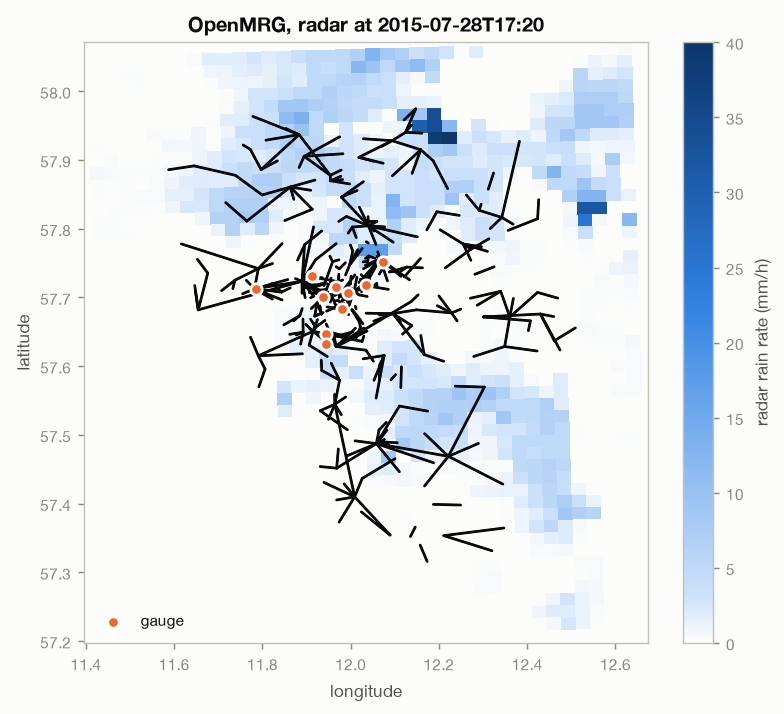

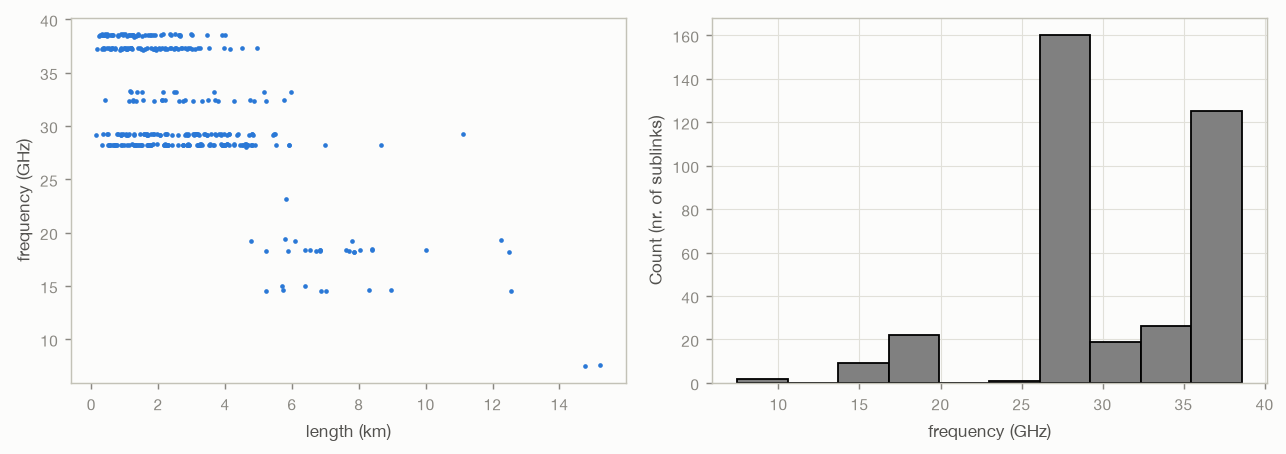

In [3]:
t_peak = int(radar.R.sum(("x", "y")).argmax())
plots.network(radar.R.isel(time=t_peak), cml, gauges,
              title=f"OpenMRG, radar at {str(radar.time.values[t_peak])[:16]}");
plots.metadata(cml);

## 3. Retrieve

`retrieve_dataset` runs `loss → wet/dry → baseline → A_obs → wet antenna →
R = (A/kL)^(1/α)` and returns every intermediate. It reads TSL when present,
scales its windows to the sampling interval, and matches per-link metadata to
sublinks by dimension name.

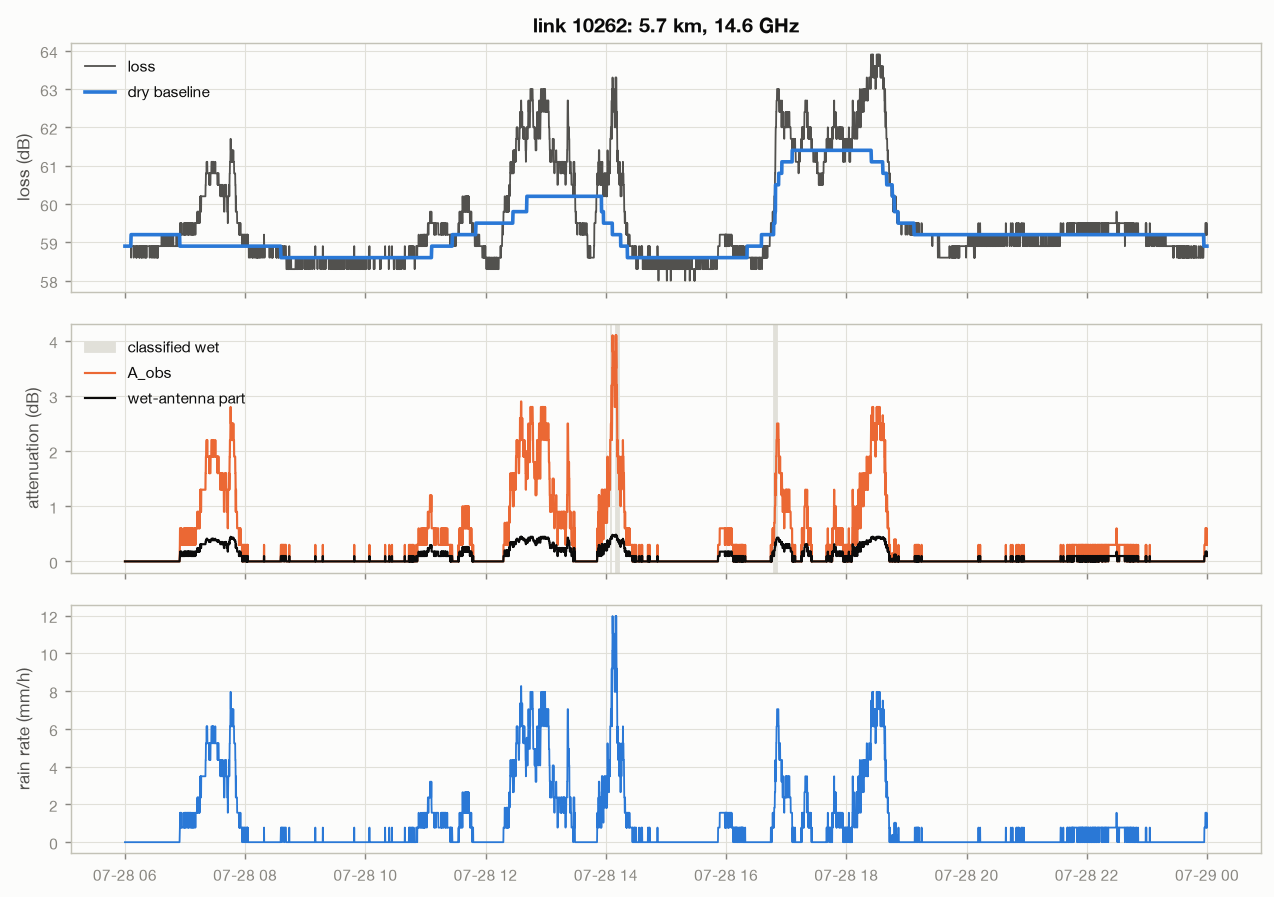

In [4]:
default = rt.retrieve_dataset(cml)

# example link: most rain seen by the radar along its path, > 2 km, reporting
radar_path = ev.radar_along_links(radar.R, cml)
reporting = default.R.notnull().all("sublink_id").mean("time") > 0.95
link = radar_path.cml_id.values[int(radar_path.sum("time").where(
    (cml.length_km > 2) & reporting).argmax())]
plots.retrieval_steps(cml, default, link);

The dry baseline **climbs during the rain** at 12-14 h and 17-18 h: the
rolling-std classifier calls the steadier parts of the rain dry and the
baseline learns them. Section 5 fixes that.

## 4. Score

Each comparison on a like-for-like support, with `poligrain` underneath:
radar path-averaged along each link, gauges within 1 km of a link *path*,
and skill as ratio of totals, correlation, and wet/dry MCC.

In [5]:
gauge_at_links = ev.gauge_series_at_links(
    ev.aggregate(gauges.R, "15min"), ev.closest_gauges(cml, gauges, 1000))
references = {"gauges": (gauge_at_links, "15min"), "radar": (radar_path, "5min")}

estimates = {"default": rt.combine_sublinks(default).R,
             "OpenSense reference R": cml.R.mean("sublink_id")}
ev.skill_table(estimates, references).round(3)

gauges                radar              
                       ratio      r    mcc  ratio      r    mcc
default                1.825  0.652  0.409  2.329  0.405  0.413
OpenSense reference R  0.930  0.663  0.621  1.416  0.394  0.639

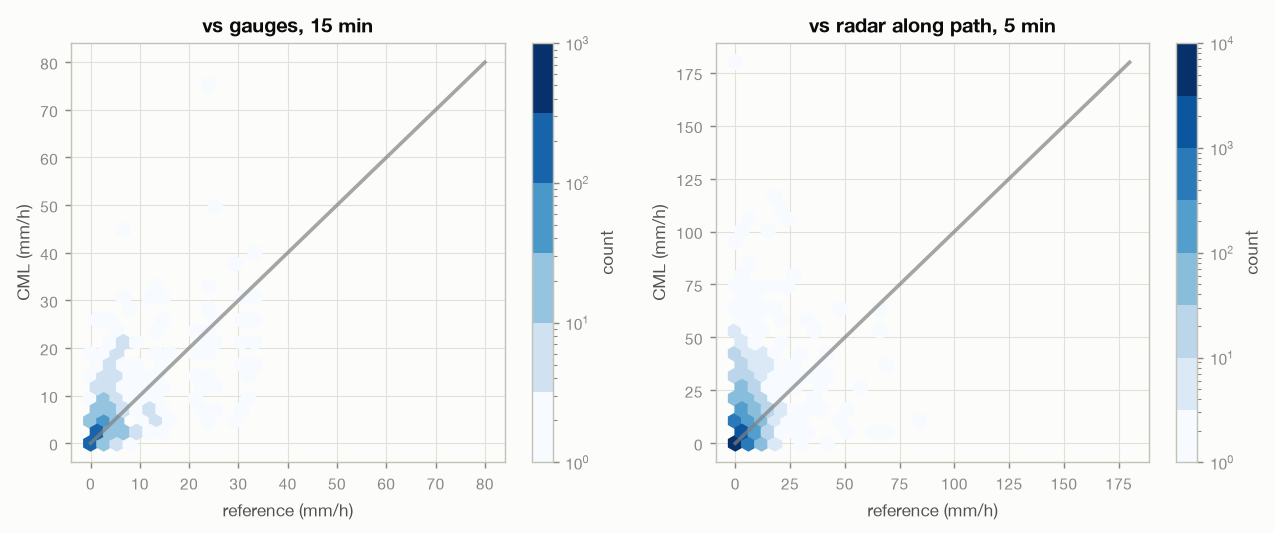

In [6]:
plots.hexbins({"vs gauges, 15 min": (gauge_at_links, ev.aggregate(estimates["default"], "15min")),
               "vs radar along path, 5 min": (radar_path, ev.aggregate(estimates["default"], "5min"))});

## 5. Improve

`retrieve_improved` swaps in the nearby-link wet/dry test (Overeem et al.
2016) and the Leijnse et al. (2008) wet-antenna model, and masks samples at a
receiver's sensitivity floor. Across OpenMRG and OpenRainER it beats the
default on every link-level score (`src/retrieval_benchmark.py`). It has **not**
yet given better merged maps: correlation rises, so does the magnitude bias.

The nearby test needs a day of history, so it runs on all 8 days and is cut
to the window.

In [7]:
full = example_data.load("openmrg", "8d", components=("cml",), verbose=False)["cml"]
improved = rt.retrieve_improved(full).sel(time=cml.time)
del full

estimates["retrieve_improved"] = rt.combine_sublinks(improved).R
ev.skill_table(estimates, references).round(3)

gauges                radar              
                       ratio      r    mcc  ratio      r    mcc
default                1.825  0.652  0.409  2.329  0.405  0.413
OpenSense reference R  0.930  0.663  0.621  1.416  0.394  0.639
retrieve_improved      1.129  0.677  0.662  1.450  0.410  0.565

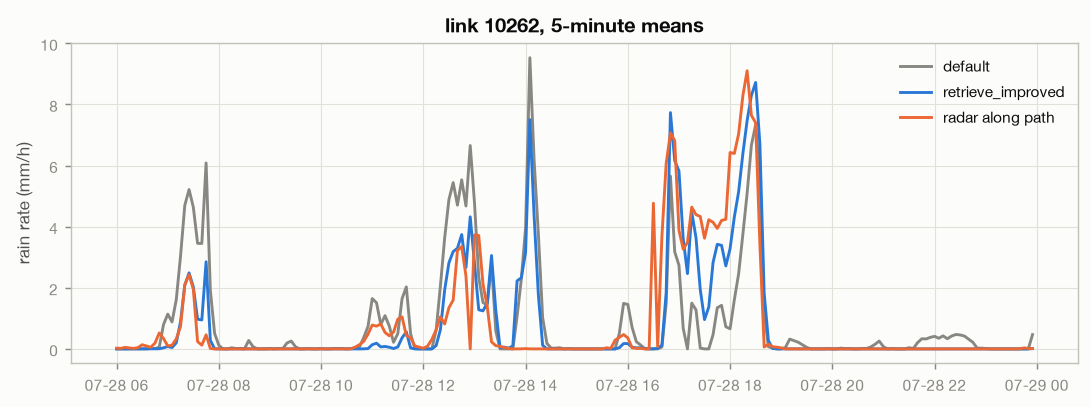

In [8]:
plots.series({"default": ev.aggregate(estimates["default"].sel(cml_id=link), "5min"),
              "retrieve_improved": ev.aggregate(estimates["retrieve_improved"].sel(cml_id=link), "5min"),
              "radar along path": radar_path.sel(cml_id=link)},
             title=f"link {link}, 5-minute means");

## 6. Map

`merging.run` gives every `mergeplg` method the same call. CML-only
line-aware IDW, and an additive radar + CML merge, at the wettest 5 minutes
on the network.

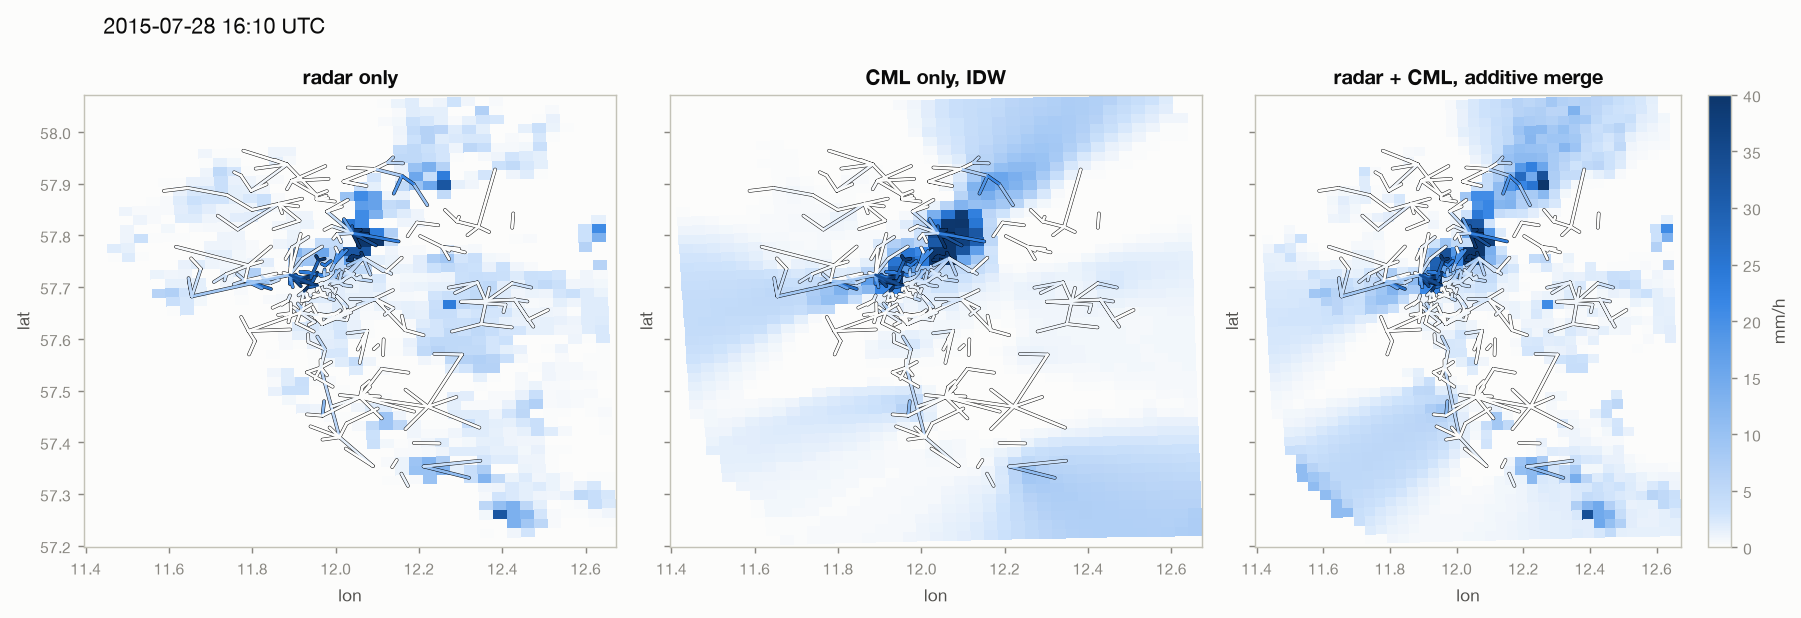

In [9]:
per_link = ev.aggregate(estimates["retrieve_improved"], "5min")
t = per_link.time.values[int(per_link.sum("cml_id").argmax())]
da_rad, da_cml = radar.R.sel(time=t), per_link.sel(time=t).dropna("cml_id")

methods = {m.key: m for m in merging.METHODS}
fields = {"radar only": da_rad,
          "CML only, IDW": merging.run(methods["cml_idw"], da_rad, da_cml),
          "radar + CML, additive merge": merging.run(methods["merge_idw_add"], da_rad, da_cml)}
plots.map_panels(fields, radar.lon, radar.lat, links=da_cml,
                 title=f"{str(t)[:16].replace('T', ' ')} UTC");

## Next

| to | run |
|---|---|
| rank retrieval variants, two networks | `src/retrieval_benchmark.py [--dataset openrainer]` |
| check against the OpenSense reference | `src/validate_retrieval.py --offline` |
| merge methods, synthetic then real | `src/run_pipeline.py [--retrieval improved --val-select gauge]` |
| radar vs CML through eight events | `src/compare_radar_cml.py --all` |
| the tests behind every call above | `python -m pytest` |